In [ ]:
# Ejecucion local: no se monta Google Drive.
from pathlib import Path
print(f"Directorio de trabajo: {Path.cwd()}")


Mounted at /content/drive


In [1]:
# ============================================================
# 1. IMPORTAR LIBRERÍAS NECESARIAS
# ============================================================

import pandas as pd
import numpy as np

# ============================================================
# 2. CARGAR DATASET DESDE ARCHIVO XLSX
# ============================================================
# En Google Colab puedes subir el archivo manualmente o montarlo desde Drive.
# Aquí asumimos que el archivo está en la ruta actual de trabajo.

ruta_archivo = "df_consumo_bime_clima_v3.xlsx"   # <-- Cambia este nombre por el tuyo

# Leer archivo Excel
df = pd.read_excel(ruta_archivo)

# Mostrar primeras filas para verificar carga correcta
print("Dataset cargado correctamente.")
display(df.head())

# Mostrar dimensiones iniciales
print(f"\nDimensiones iniciales del dataset: {df.shape}")

# ============================================================
# 3. DEFINIR VARIABLE OBJETIVO (TARGET)
# ============================================================

target = "consumo_promedio"

# Verificar que exista en el dataset
if target not in df.columns:
    raise ValueError(f"La variable objetivo '{target}' no existe en el dataset.")

# ============================================================
# 4. VARIABLES A ELIMINAR SEGÚN ANÁLISIS DE INGENIERÍA
# ============================================================

columnas_eliminar = [

    # --------------------------------------------------------
    # Variables con posible DATA LEAKAGE
    # (Muy relacionadas o derivadas directamente del target)
    # --------------------------------------------------------
    "metros_cubicos",
    "facturas",
    "suscriptores_facturados",
    "suscriptores_con_medidor",

    # --------------------------------------------------------
    # Variables categóricas / geográficas inicialmente removidas
    # --------------------------------------------------------

    # --------------------------------------------------------
    # Variables climáticas redundantes / derivadas
    # --------------------------------------------------------
    "T2MWET",
    "T2MDEW",
    "T2M_RANGE",

    # --------------------------------------------------------
    # Variables de viento redundantes
    # --------------------------------------------------------
    "WS10M_MAX",
    "WS10M_MIN",
    "WS10M_RANGE",
    "WS2M_MAX",
    "WS2M_MIN",
    "WS2M_RANGE",

    # --------------------------------------------------------
    # Variables angulares inicialmente removidas
    # (Dirección del viento requiere transformación trigonométrica)
    # --------------------------------------------------------
    "WD10M",
    "WD2M",

    # --------------------------------------------------------
    # Variables radiativas redundantes
    # --------------------------------------------------------
    "ALLSKY_SFC_PAR_TOT",
    "CLRSKY_SFC_PAR_TOT",
    "ALLSKY_SFC_SW_DIFF",
    "ALLSKY_SFC_SW_DNI",
    "ALLSKY_SFC_UVA",
    "ALLSKY_SFC_UVB",
    "ALLSKY_SFC_UV_INDEX",
    "CLRSKY_SFC_SW_DWN",
    "TOA_SW_DWN"
]

# ============================================================
# 5. ELIMINAR SOLO COLUMNAS EXISTENTES (ROBUSTEZ)
# ============================================================
# Esto evita errores si alguna columna no está en el archivo.

columnas_existentes_eliminar = [
    col for col in columnas_eliminar if col in df.columns
]

df = df.drop(columns=columnas_existentes_eliminar)

# Mostrar columnas eliminadas
print("\nColumnas eliminadas:")
for col in columnas_existentes_eliminar:
    print(f" - {col}")

# ============================================================
# 6. SEPARAR FEATURES (X) Y TARGET (y)
# ============================================================

X = df.drop(columns=[target])
y = df[target]

# ============================================================
# 7. MOSTRAR RESUMEN FINAL
# ============================================================

print("\n==============================")
print("PREPROCESAMIENTO COMPLETADO")
print("==============================")

print(f"\nNúmero final de features: {X.shape[1]}")
print(f"Número de muestras: {X.shape[0]}")

print("\nFeatures finales utilizadas:")
for col in X.columns:
    print(f" - {col}")

# ============================================================
# 8. VISTA PRELIMINAR DEL DATASET LIMPIO
# ============================================================

display(X.head())

print("\nTarget preview:")
display(y.head())

Dataset cargado correctamente.


,año,localidad,BIMESTRE,metros_cubicos,facturas,consumo_promedio,suscriptores_facturados,suscriptores_con_medidor,latitud,longitud,...,WD10M,WD2M,WS10M,WS10M_MAX,WS10M_MIN,WS10M_RANGE,WS2M,WS2M_MAX,WS2M_MIN,WS2M_RANGE
0,2020,USAQUEN,1,4653292,213354,10.905097,212731.0,215097,4.73197,-74.05163,...,89.65,94.8,2.310,6.405,0.140,3.07,1.395,4.175,0.065,2.085
1,2020,CHAPINERO,1,2281601,93362,12.219109,93016.0,93684,4.67040,-74.04338,...,89.65,94.8,2.310,6.405,0.140,3.07,1.395,4.175,0.065,2.085
2,2020,SANTA FE,1,843631,33789,12.483811,33524.0,34703,4.60947,-74.08135,...,78.20,78.8,2.275,6.650,0.205,2.31,1.430,4.735,0.150,1.945
3,2020,SAN CRISTOBAL,1,1771678,80676,10.980205,80311.0,81072,4.58843,-74.07080,...,78.20,78.8,2.275,6.650,0.205,2.31,1.430,4.735,0.150,1.945
4,2020,USME,1,1570282,78240,10.035033,77876.0,79159,4.53286,-74.11451,...,78.20,78.8,2.275,6.650,0.205,2.31,1.430,4.735,0.150,1.945



Dimensiones iniciales del dataset: (596, 49)

Columnas eliminadas:
 - metros_cubicos
 - facturas
 - suscriptores_facturados
 - suscriptores_con_medidor
 - T2MWET
 - T2MDEW
 - T2M_RANGE
 - WS10M_MAX
 - WS10M_MIN
 - WS10M_RANGE
 - WS2M_MAX
 - WS2M_MIN
 - WS2M_RANGE
 - WD10M
 - WD2M
 - ALLSKY_SFC_PAR_TOT
 - CLRSKY_SFC_PAR_TOT
 - ALLSKY_SFC_SW_DIFF
 - ALLSKY_SFC_SW_DNI
 - ALLSKY_SFC_UVA
 - ALLSKY_SFC_UVB
 - ALLSKY_SFC_UV_INDEX
 - CLRSKY_SFC_SW_DWN
 - TOA_SW_DWN

PREPROCESAMIENTO COMPLETADO

Número final de features: 24
Número de muestras: 596

Features finales utilizadas:
 - año
 - localidad
 - BIMESTRE
 - latitud
 - longitud
 - ALLSKY_SFC_LW_DWN
 - ALLSKY_SFC_SW_DWN
 - ALLSKY_SRF_ALB
 - CLOUD_AMT
 - GWETPROF
 - GWETROOT
 - GWETTOP
 - ONI
 - PRECTOTCORR
 - PRECTOTCORR_SUM
 - PS
 - QV2M
 - RH2M
 - T2M
 - T2M_MAX
 - T2M_MIN
 - TS
 - WS10M
 - WS2M


,año,localidad,BIMESTRE,latitud,longitud,ALLSKY_SFC_LW_DWN,ALLSKY_SFC_SW_DWN,ALLSKY_SRF_ALB,CLOUD_AMT,GWETPROF,...,PRECTOTCORR_SUM,PS,QV2M,RH2M,T2M,T2M_MAX,T2M_MIN,TS,WS10M,WS2M
0,2020,USAQUEN,1,4.73197,-74.05163,31.615,19.135,0.15,62.185,0.775,...,59.16,79.585,11.865,83.595,16.04,22.470,8.820,16.32,2.310,1.395
1,2020,CHAPINERO,1,4.67040,-74.04338,31.615,19.135,0.15,62.185,0.775,...,59.16,79.585,11.865,83.595,16.04,22.470,8.820,16.32,2.310,1.395
2,2020,SANTA FE,1,4.60947,-74.08135,31.615,19.135,0.15,62.185,0.705,...,77.95,82.335,12.860,78.225,19.06,27.045,9.945,19.24,2.275,1.430
3,2020,SAN CRISTOBAL,1,4.58843,-74.07080,31.615,19.135,0.15,62.185,0.705,...,77.95,82.335,12.860,78.225,19.06,27.045,9.945,19.24,2.275,1.430
4,2020,USME,1,4.53286,-74.11451,31.615,19.135,0.15,62.185,0.705,...,77.95,82.335,12.860,78.225,19.06,27.045,9.945,19.24,2.275,1.430



Target preview:


0    10.905097
1    12.219109
2    12.483811
3    10.980205
4    10.035033
Name: consumo_promedio, dtype: float64

Se transformó 'BIMESTRE' a variables cíclicas: BIMESTRE_sin y BIMESTRE_cos
Se aplicó transformación log1p al target 'consumo_promedio'.

Después de quitar targets nulos:
X_model: (596, 25)
y_model: (596,)

Localidades encontradas:
 - ANTONIO NARINO
 - BARRIOS UNIDOS
 - BOSA
 - CHAPINERO
 - CIUDAD BOLIVAR
 - ENGATIVA
 - FONTIBON
 - KENNEDY
 - LA CANDELARIA
 - LOS MARTIRES
 - PUENTE ARANDA
 - RAFAEL URIBE URIBE
 - SAN CRISTOBAL
 - SANTA FE
 - SUBA
 - SUMAPAZ
 - TEUSAQUILLO
 - TUNJUELITO
 - USAQUEN
 - USME

Total de localidades: 20

Fold 1/20 - Localidad en TEST: ANTONIO NARINO
Tamaño train: (452, 24)
Tamaño val:   (114, 24)
Tamaño test:  (30, 24)
TRAIN -> MAE: 0.3207 | RMSE: 0.4973 | R²: 0.9704
VAL   -> MAE: 0.7455 | RMSE: 1.7304 | R²: 0.7814
TEST  -> MAE: 0.2364 | RMSE: 0.3140 | R²: 0.7405

Fold 2/20 - Localidad en TEST: BARRIOS UNIDOS
Tamaño train: (452, 24)
Tamaño val:   (114, 24)
Tamaño test:  (30, 24)
TRAIN -> MAE: 0.3101 | RMSE: 0.4859 | R²: 0.9719
VAL   -> MAE: 0.7371 | RMSE: 1.76

,localidad_test,n_train,n_val,n_test,MAE_train,RMSE_train,R2_train,MAE_val,RMSE_val,R2_val,MAE_test,RMSE_test,R2_test
0,ANTONIO NARINO,452,114,30,0.320733,0.497277,0.970407,0.745495,1.730359,0.781367,0.236418,0.314039,0.740476
13,SANTA FE,452,114,30,0.300659,0.480085,0.972344,0.701254,1.663520,0.792656,0.585194,0.714372,0.325445
3,CHAPINERO,452,114,30,0.282955,0.442270,0.976403,0.699645,1.710220,0.780443,0.785804,0.875714,0.223170
6,FONTIBON,452,114,30,0.307744,0.474169,0.973047,0.722312,1.756513,0.774429,0.568522,0.638668,-0.044630
11,RAFAEL URIBE URIBE,452,114,30,0.330667,0.505183,0.971562,0.678476,1.723773,0.743534,0.491383,0.562104,-0.304703
1,BARRIOS UNIDOS,452,114,30,0.310121,0.485866,0.971866,0.737122,1.760679,0.773894,0.655362,0.718409,-0.353067
15,SUMAPAZ,456,114,26,0.225425,0.335703,0.974682,0.300094,0.456759,0.946994,9.206282,11.855792,-0.986914
8,LA CANDELARIA,452,114,30,0.270375,0.392368,0.978545,0.607869,1.579982,0.773929,3.263190,3.824351,-1.684135
14,SUBA,452,114,30,0.311501,0.478670,0.972296,0.727698,1.739470,0.775825,0.515219,0.571850,-1.894091
4,CIUDAD BOLIVAR,452,114,30,0.319786,0.493797,0.972734,0.646651,1.711711,0.746759,0.689272,0.721569,-2.028858



RESUMEN GLOBAL LEAVE-ONE-LOCALIDAD-OUT
Promedio MAE test : 2.2780
Promedio RMSE test: 2.5129
Promedio R² test  : -48.5812

Mediana MAE test : 0.9091
Mediana RMSE test: 0.9962
Mediana R² test  : -2.5484

Top 5 mejores localidades por R² test:


,localidad_test,n_train,n_val,n_test,MAE_train,RMSE_train,R2_train,MAE_val,RMSE_val,R2_val,MAE_test,RMSE_test,R2_test
0,ANTONIO NARINO,452,114,30,0.320733,0.497277,0.970407,0.745495,1.730359,0.781367,0.236418,0.314039,0.740476
13,SANTA FE,452,114,30,0.300659,0.480085,0.972344,0.701254,1.663520,0.792656,0.585194,0.714372,0.325445
3,CHAPINERO,452,114,30,0.282955,0.442270,0.976403,0.699645,1.710220,0.780443,0.785804,0.875714,0.223170
6,FONTIBON,452,114,30,0.307744,0.474169,0.973047,0.722312,1.756513,0.774429,0.568522,0.638668,-0.044630
11,RAFAEL URIBE URIBE,452,114,30,0.330667,0.505183,0.971562,0.678476,1.723773,0.743534,0.491383,0.562104,-0.304703



Top 5 peores localidades por R² test:


,localidad_test,n_train,n_val,n_test,MAE_train,RMSE_train,R2_train,MAE_val,RMSE_val,R2_val,MAE_test,RMSE_test,R2_test
19,USME,452,114,30,0.300518,0.472353,0.973016,0.707153,1.661717,0.792056,7.283998,7.637603,-792.230271
5,ENGATIVA,452,114,30,0.315130,0.491462,0.970888,0.755988,1.754243,0.772508,2.483863,2.510240,-43.630349
9,LOS MARTIRES,452,114,30,0.308148,0.481671,0.972347,0.724966,1.686251,0.792963,4.374474,4.460659,-36.092634
10,PUENTE ARANDA,452,114,30,0.286224,0.459313,0.971503,0.687348,1.724122,0.764498,5.682640,5.737242,-28.936511
2,BOSA,452,114,30,0.305915,0.471045,0.972930,0.690252,1.694405,0.782220,1.246957,1.272344,-24.996781


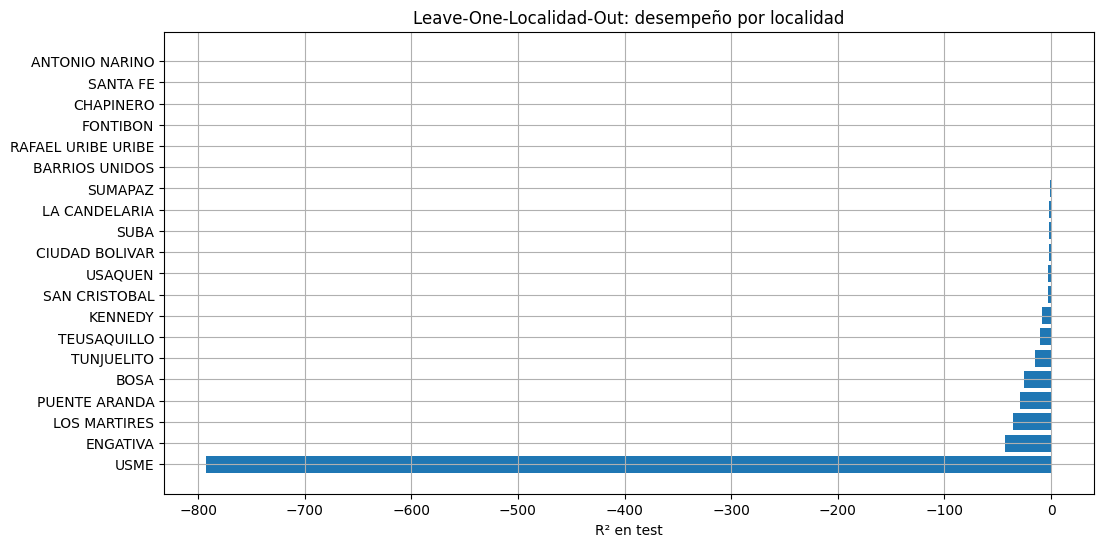

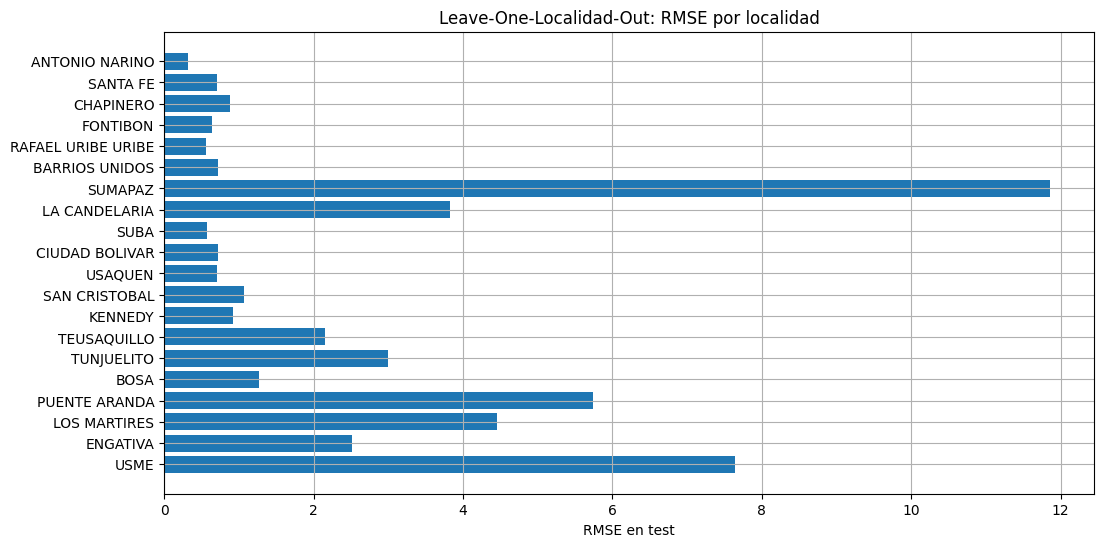


Primeras filas de predicciones espaciales:


,localidad,Valor_real,Prediccion,Error_absoluto
0,ANTONIO NARINO,11.543004,11.381996,0.161008
1,ANTONIO NARINO,11.456785,11.017457,0.439328
2,ANTONIO NARINO,10.910801,10.981621,0.070820
3,ANTONIO NARINO,11.060142,11.057124,0.003018
4,ANTONIO NARINO,11.036871,11.038781,0.001910
5,ANTONIO NARINO,11.303807,11.446127,0.142320
6,ANTONIO NARINO,10.996361,10.622306,0.374056
7,ANTONIO NARINO,11.212705,11.206242,0.006463
8,ANTONIO NARINO,10.927449,10.841421,0.086028
9,ANTONIO NARINO,10.889081,10.943257,0.054177



Se guardó el resumen por localidad en: resultados_leave_one_localidad_out.csv
Se guardaron las predicciones por localidad en: predicciones_leave_one_localidad_out.csv


In [3]:
# ============================================================
# VALIDACIÓN ESPACIAL: LEAVE-ONE-LOCALIDAD-OUT CON XGBOOST
# ============================================================
# Este bloque evalúa si el modelo generaliza a localidades no vistas.
#
# Para cada localidad:
# - se deja esa localidad completa como TEST
# - se entrena con las demás localidades
# - se crea un split interno train/validation dentro del resto
# - se imputan valores faltantes
# - se entrena XGBoost
# - se evalúa sobre la localidad excluida
# - se guarda el desempeño por localidad
#
# REQUISITOS:
# Deben existir previamente:
#   X
#   y
#
# IMPORTANTE:
# - X debe conservar la columna "localidad"
# - X puede contener "BIMESTRE"
# - y está en escala original; aquí se transforma con log1p
# ============================================================

# Instalar/importar XGBoost si hace falta
try:
    from xgboost import XGBRegressor
except ImportError:
    # !pip install xgboost -q
    from xgboost import XGBRegressor

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ============================================================
# 1. CONSTRUIR X_model Y y_model DENTRO DEL MISMO BLOQUE
# ============================================================

X_model = X.copy()
y_model = y.copy()

# ------------------------------------------------------------
# 1.1 TRANSFORMAR BIMESTRE A REPRESENTACIÓN CÍCLICA
# ------------------------------------------------------------

if "BIMESTRE" in X_model.columns:
    X_model["BIMESTRE"] = pd.to_numeric(X_model["BIMESTRE"], errors="coerce")
    X_model["BIMESTRE_sin"] = np.sin(2 * np.pi * X_model["BIMESTRE"] / 6)
    X_model["BIMESTRE_cos"] = np.cos(2 * np.pi * X_model["BIMESTRE"] / 6)
    X_model = X_model.drop(columns=["BIMESTRE"])
    print("Se transformó 'BIMESTRE' a variables cíclicas: BIMESTRE_sin y BIMESTRE_cos")
else:
    print("La columna 'BIMESTRE' no está presente en X_model")

# ------------------------------------------------------------
# 1.2 CONVERTIR COLUMNAS NUMÉRICAS
# ------------------------------------------------------------
# No convertimos 'localidad' porque la usaremos para definir los folds espaciales.

for col in X_model.columns:
    if col != "localidad":
        X_model[col] = pd.to_numeric(X_model[col], errors="coerce")

# Convertir target a numérico
y_model = pd.to_numeric(y_model, errors="coerce")

# ------------------------------------------------------------
# 1.3 TRANSFORMAR EL TARGET CON log1p
# ------------------------------------------------------------

if (y_model < 0).any():
    raise ValueError("La transformación log1p no puede aplicarse porque existen valores negativos en el target.")

y_model = np.log1p(y_model)

print("Se aplicó transformación log1p al target 'consumo_promedio'.")

# ------------------------------------------------------------
# 1.4 ELIMINAR FILAS DONDE EL TARGET SEA NULO
# ------------------------------------------------------------

mask_target_valido = y_model.notna()

X_model = X_model.loc[mask_target_valido].reset_index(drop=True)
y_model = y_model.loc[mask_target_valido].reset_index(drop=True)

print("\nDespués de quitar targets nulos:")
print(f"X_model: {X_model.shape}")
print(f"y_model: {y_model.shape}")

# ============================================================
# 2. VERIFICAR QUE EXISTA LA COLUMNA LOCALIDAD
# ============================================================

if "localidad" not in X_model.columns:
    raise ValueError(
        "La columna 'localidad' no está en X. "
        "Debes conservarla en el dataset para la validación espacial."
    )

# ============================================================
# 3. FUNCIÓN AUXILIAR PARA MÉTRICAS
# ============================================================

def calcular_metricas(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    return mae, rmse, r2

# ============================================================
# 4. LISTAR LOCALIDADES DISPONIBLES
# ============================================================

localidades = sorted(X_model["localidad"].dropna().unique().tolist())

print("\nLocalidades encontradas:")
for loc in localidades:
    print(f" - {loc}")

print(f"\nTotal de localidades: {len(localidades)}")

# ============================================================
# 5. DEFINIR HIPERPARÁMETROS DEL MEJOR XGBOOST
# ============================================================

xgb_params = {
    "n_estimators": 400,
    "learning_rate": 0.03,
    "max_depth": 3,
    "min_child_weight": 1,
    "subsample": 0.8,
    "colsample_bytree": 1.0,
    "reg_alpha": 0.0,
    "reg_lambda": 1.0,
    "objective": "reg:squarederror",
    "random_state": 42,
    "n_jobs": -1
}

# ============================================================
# 6. RECORRER CADA LOCALIDAD COMO TEST
# ============================================================

resultados_localidad = []
predicciones_por_localidad = {}

for i, loc_test in enumerate(localidades, start=1):
    print("\n" + "=" * 80)
    print(f"Fold {i}/{len(localidades)} - Localidad en TEST: {loc_test}")
    print("=" * 80)

    # --------------------------------------------------------
    # 6.1 Separar TEST: toda la localidad actual
    # --------------------------------------------------------
    mask_test = X_model["localidad"] == loc_test

    X_test_loc = X_model.loc[mask_test].copy()
    y_test_loc = y_model.loc[mask_test].copy()

    X_rest = X_model.loc[~mask_test].copy()
    y_rest = y_model.loc[~mask_test].copy()

    if len(X_test_loc) < 2 or len(X_rest) < 10:
        print(f"Se omite la localidad {loc_test} por tamaño insuficiente.")
        continue

    # --------------------------------------------------------
    # 6.2 Quitar 'localidad' de las features del modelo
    # --------------------------------------------------------
    X_test_loc_features = X_test_loc.drop(columns=["localidad"])
    X_rest_features = X_rest.drop(columns=["localidad"])

    # --------------------------------------------------------
    # 6.3 Crear split interno train/validation
    # --------------------------------------------------------
    X_train_loc, X_val_loc, y_train_loc, y_val_loc = train_test_split(
        X_rest_features,
        y_rest,
        test_size=0.20,
        random_state=42
    )

    print(f"Tamaño train: {X_train_loc.shape}")
    print(f"Tamaño val:   {X_val_loc.shape}")
    print(f"Tamaño test:  {X_test_loc_features.shape}")

    # --------------------------------------------------------
    # 6.4 Imputar valores faltantes
    # --------------------------------------------------------
    imputer = SimpleImputer(strategy="median")

    X_train_imp = imputer.fit_transform(X_train_loc)
    X_val_imp   = imputer.transform(X_val_loc)
    X_test_imp  = imputer.transform(X_test_loc_features)

    # --------------------------------------------------------
    # 6.5 Entrenar XGBoost
    # --------------------------------------------------------
    model = XGBRegressor(**xgb_params)

    model.fit(
        X_train_imp,
        y_train_loc.values,
        eval_set=[(X_val_imp, y_val_loc.values)],
        verbose=False
    )

    # --------------------------------------------------------
    # 6.6 Predecir
    # --------------------------------------------------------
    y_train_pred_log = model.predict(X_train_imp)
    y_val_pred_log   = model.predict(X_val_imp)
    y_test_pred_log  = model.predict(X_test_imp)

    # --------------------------------------------------------
    # 6.7 Volver a escala original
    # --------------------------------------------------------
    y_train_real = np.expm1(y_train_loc.values)
    y_val_real   = np.expm1(y_val_loc.values)
    y_test_real  = np.expm1(y_test_loc.values)

    y_train_pred_real = np.expm1(y_train_pred_log)
    y_val_pred_real   = np.expm1(y_val_pred_log)
    y_test_pred_real  = np.expm1(y_test_pred_log)

    # --------------------------------------------------------
    # 6.8 Calcular métricas
    # --------------------------------------------------------
    mae_train, rmse_train, r2_train = calcular_metricas(y_train_real, y_train_pred_real)
    mae_val, rmse_val, r2_val       = calcular_metricas(y_val_real, y_val_pred_real)
    mae_test, rmse_test, r2_test    = calcular_metricas(y_test_real, y_test_pred_real)

    print(f"TRAIN -> MAE: {mae_train:.4f} | RMSE: {rmse_train:.4f} | R²: {r2_train:.4f}")
    print(f"VAL   -> MAE: {mae_val:.4f} | RMSE: {rmse_val:.4f} | R²: {r2_val:.4f}")
    print(f"TEST  -> MAE: {mae_test:.4f} | RMSE: {rmse_test:.4f} | R²: {r2_test:.4f}")

    # --------------------------------------------------------
    # 6.9 Guardar resultados
    # --------------------------------------------------------
    resultados_localidad.append({
        "localidad_test": loc_test,
        "n_train": len(X_train_loc),
        "n_val": len(X_val_loc),
        "n_test": len(X_test_loc_features),
        "MAE_train": mae_train,
        "RMSE_train": rmse_train,
        "R2_train": r2_train,
        "MAE_val": mae_val,
        "RMSE_val": rmse_val,
        "R2_val": r2_val,
        "MAE_test": mae_test,
        "RMSE_test": rmse_test,
        "R2_test": r2_test
    })

    predicciones_por_localidad[loc_test] = pd.DataFrame({
        "localidad": loc_test,
        "Valor_real": y_test_real,
        "Prediccion": y_test_pred_real,
        "Error_absoluto": np.abs(y_test_real - y_test_pred_real)
    })

# ============================================================
# 7. CONSTRUIR TABLA FINAL DE RESULTADOS
# ============================================================

df_resultados_spatial = pd.DataFrame(resultados_localidad)

if df_resultados_spatial.empty:
    raise ValueError("No se generaron resultados. Revisa la columna 'localidad' y los tamaños de muestra.")

print("\n" + "=" * 80)
print("RESULTADOS POR LOCALIDAD (TEST)")
print("=" * 80)
display(df_resultados_spatial.sort_values(by="R2_test", ascending=False))

# ============================================================
# 8. RESUMEN GLOBAL
# ============================================================

print("\n" + "=" * 80)
print("RESUMEN GLOBAL LEAVE-ONE-LOCALIDAD-OUT")
print("=" * 80)

print(f"Promedio MAE test : {df_resultados_spatial['MAE_test'].mean():.4f}")
print(f"Promedio RMSE test: {df_resultados_spatial['RMSE_test'].mean():.4f}")
print(f"Promedio R² test  : {df_resultados_spatial['R2_test'].mean():.4f}")

print(f"\nMediana MAE test : {df_resultados_spatial['MAE_test'].median():.4f}")
print(f"Mediana RMSE test: {df_resultados_spatial['RMSE_test'].median():.4f}")
print(f"Mediana R² test  : {df_resultados_spatial['R2_test'].median():.4f}")

# ============================================================
# 9. MEJORES Y PEORES LOCALIDADES
# ============================================================

print("\nTop 5 mejores localidades por R² test:")
display(df_resultados_spatial.sort_values(by="R2_test", ascending=False).head(5))

print("\nTop 5 peores localidades por R² test:")
display(df_resultados_spatial.sort_values(by="R2_test", ascending=True).head(5))

# ============================================================
# 10. GRÁFICO DE R² POR LOCALIDAD
# ============================================================

df_plot = df_resultados_spatial.sort_values(by="R2_test", ascending=True)

plt.figure(figsize=(12, 6))
plt.barh(df_plot["localidad_test"].astype(str), df_plot["R2_test"])
plt.xlabel("R² en test")
plt.title("Leave-One-Localidad-Out: desempeño por localidad")
plt.grid(True)
plt.show()

# ============================================================
# 11. GRÁFICO DE RMSE POR LOCALIDAD
# ============================================================

plt.figure(figsize=(12, 6))
plt.barh(df_plot["localidad_test"].astype(str), df_plot["RMSE_test"])
plt.xlabel("RMSE en test")
plt.title("Leave-One-Localidad-Out: RMSE por localidad")
plt.grid(True)
plt.show()

# ============================================================
# 12. UNIR TODAS LAS PREDICCIONES DE TEST
# ============================================================

df_predicciones_spatial = pd.concat(predicciones_por_localidad.values(), ignore_index=True)

print("\nPrimeras filas de predicciones espaciales:")
display(df_predicciones_spatial.head(10))

# ============================================================
# 13. GUARDAR RESULTADOS
# ============================================================

ruta_resultados_localidad = "resultados_leave_one_localidad_out.csv"
ruta_predicciones_localidad = "predicciones_leave_one_localidad_out.csv"

df_resultados_spatial.to_csv(ruta_resultados_localidad, index=False)
df_predicciones_spatial.to_csv(ruta_predicciones_localidad, index=False)

print(f"\nSe guardó el resumen por localidad en: {ruta_resultados_localidad}")
print(f"Se guardaron las predicciones por localidad en: {ruta_predicciones_localidad}")


ESTADÍSTICAS DEL TARGET POR LOCALIDAD


,localidad,count,mean,median,std,min,max,range,coef_var
15,SUMAPAZ,26,17.998345,18.012019,8.577441,5.080645,38.411765,33.331120,0.476568
8,LA CANDELARIA,30,16.498552,16.791211,2.374200,11.609348,21.308195,9.698847,0.143904
10,PUENTE ARANDA,30,15.940170,15.986293,1.066508,13.672494,17.999410,4.326916,0.066907
17,TUNJUELITO,30,13.992086,14.063706,0.770559,11.547917,15.852958,4.305040,0.055071
6,FONTIBON,30,12.770533,12.774074,0.635558,11.436407,13.892788,2.456381,0.049768
9,LOS MARTIRES,30,11.312020,11.462044,0.744932,8.996992,12.387945,3.390953,0.065853
11,RAFAEL URIBE URIBE,30,11.179795,11.215600,0.500521,9.643768,12.272101,2.628333,0.044770
1,BARRIOS UNIDOS,30,11.063180,11.235347,0.628165,9.724490,12.554163,2.829674,0.056780
12,SAN CRISTOBAL,30,10.872876,10.955805,0.527396,8.892467,11.725077,2.832611,0.048506
13,SANTA FE,30,10.817082,11.048632,0.884662,8.909647,12.483811,3.574164,0.081784


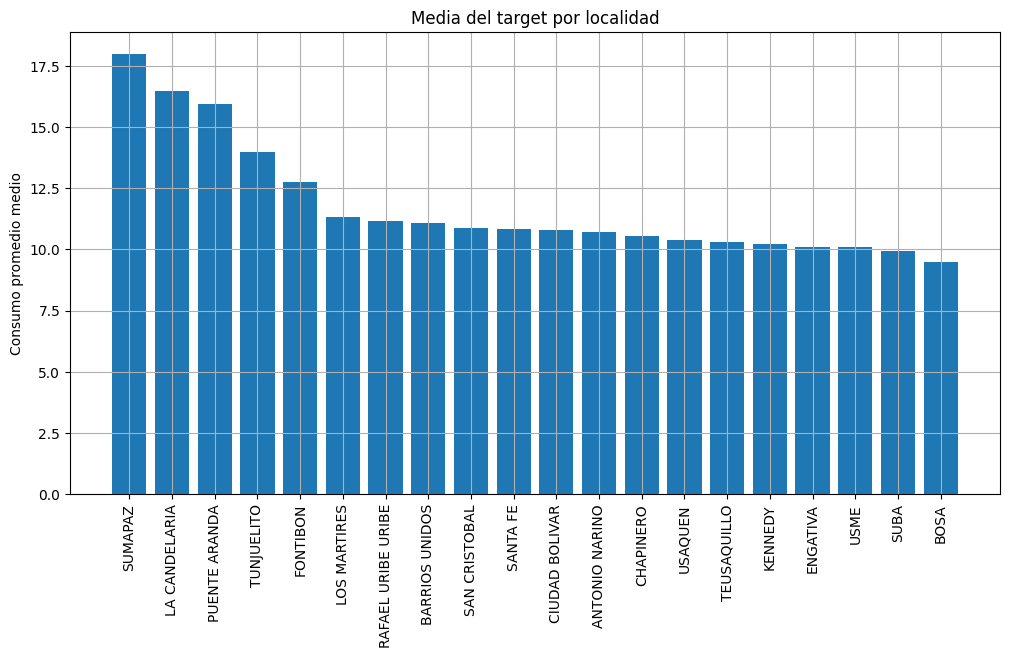

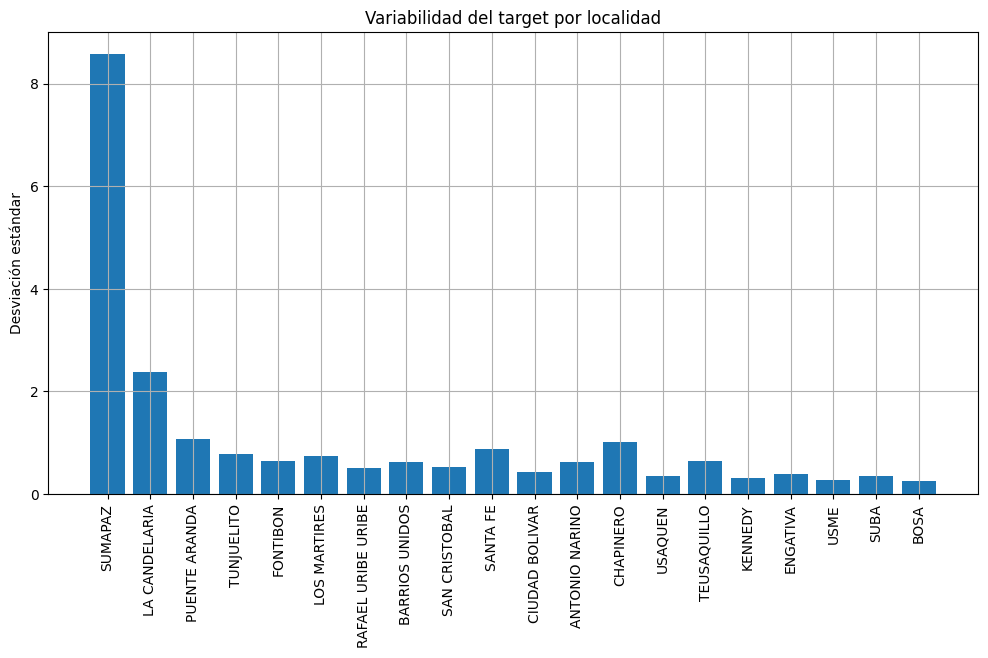


Top 5 localidades con MAYOR media de consumo:


,localidad,count,mean,median,std,min,max,range,coef_var
15,SUMAPAZ,26,17.998345,18.012019,8.577441,5.080645,38.411765,33.331120,0.476568
8,LA CANDELARIA,30,16.498552,16.791211,2.374200,11.609348,21.308195,9.698847,0.143904
10,PUENTE ARANDA,30,15.940170,15.986293,1.066508,13.672494,17.999410,4.326916,0.066907
17,TUNJUELITO,30,13.992086,14.063706,0.770559,11.547917,15.852958,4.305040,0.055071
6,FONTIBON,30,12.770533,12.774074,0.635558,11.436407,13.892788,2.456381,0.049768



Top 5 localidades con MENOR media de consumo:


,localidad,count,mean,median,std,min,max,range,coef_var
2,BOSA,30,9.504299,9.552698,0.253809,8.627833,9.826832,1.198999,0.026705
14,SUBA,30,9.948746,10.027423,0.341891,8.851619,10.384078,1.532460,0.034365
19,USME,30,10.083252,10.122439,0.275816,9.110767,10.417618,1.306851,0.027354
5,ENGATIVA,30,10.099412,10.143362,0.382175,8.938284,10.817616,1.879332,0.037841
7,KENNEDY,30,10.208592,10.284224,0.307756,9.386470,10.761761,1.375291,0.030147



Top 5 localidades con MAYOR variabilidad:


,localidad,count,mean,median,std,min,max,range,coef_var
15,SUMAPAZ,26,17.998345,18.012019,8.577441,5.080645,38.411765,33.331120,0.476568
8,LA CANDELARIA,30,16.498552,16.791211,2.374200,11.609348,21.308195,9.698847,0.143904
10,PUENTE ARANDA,30,15.940170,15.986293,1.066508,13.672494,17.999410,4.326916,0.066907
3,CHAPINERO,30,10.540054,10.662206,1.010557,8.566008,12.219109,3.653101,0.095878
13,SANTA FE,30,10.817082,11.048632,0.884662,8.909647,12.483811,3.574164,0.081784



Top 5 localidades con MAYOR coeficiente de variación:


,localidad,count,mean,median,std,min,max,range,coef_var
15,SUMAPAZ,26,17.998345,18.012019,8.577441,5.080645,38.411765,33.331120,0.476568
8,LA CANDELARIA,30,16.498552,16.791211,2.374200,11.609348,21.308195,9.698847,0.143904
3,CHAPINERO,30,10.540054,10.662206,1.010557,8.566008,12.219109,3.653101,0.095878
13,SANTA FE,30,10.817082,11.048632,0.884662,8.909647,12.483811,3.574164,0.081784
10,PUENTE ARANDA,30,15.940170,15.986293,1.066508,13.672494,17.999410,4.326916,0.066907


<Figure size 1500x700 with 0 Axes>

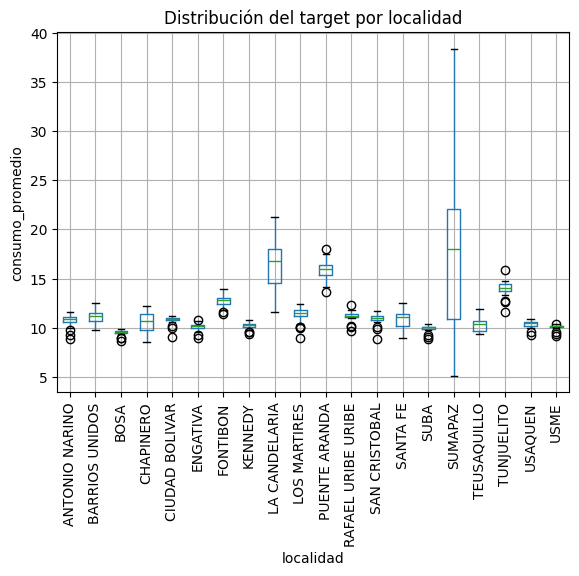

In [4]:
# ============================================================
# DIAGNÓSTICO DE LOCALIDADES: ¿POR QUÉ FALLAN ALGUNAS?
# ============================================================
# Este bloque analiza estadísticamente cada localidad para
# entender por qué algunas tienen muy mal desempeño.
#
# REQUISITOS:
# Deben existir:
#   df  -> dataset original limpio (antes de log1p)
#   target = "consumo_promedio"
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# 1. VERIFICACIONES
# ============================================================

if "localidad" not in df.columns:
    raise ValueError("El dataset df debe contener la columna 'localidad'.")

if target not in df.columns:
    raise ValueError(f"El dataset df debe contener la columna target '{target}'.")

# ============================================================
# 2. ESTADÍSTICAS DEL TARGET POR LOCALIDAD
# ============================================================

stats_localidad = df.groupby("localidad")[target].agg([
    "count",
    "mean",
    "median",
    "std",
    "min",
    "max"
]).reset_index()

stats_localidad["range"] = stats_localidad["max"] - stats_localidad["min"]
stats_localidad["coef_var"] = stats_localidad["std"] / stats_localidad["mean"]

# Ordenar por media de consumo
stats_localidad = stats_localidad.sort_values(by="mean", ascending=False)

print("\n==============================")
print("ESTADÍSTICAS DEL TARGET POR LOCALIDAD")
print("==============================")
display(stats_localidad)

# ============================================================
# 3. VISUALIZAR MEDIA DE CONSUMO POR LOCALIDAD
# ============================================================

plt.figure(figsize=(12,6))
plt.bar(stats_localidad["localidad"], stats_localidad["mean"])
plt.xticks(rotation=90)
plt.ylabel("Consumo promedio medio")
plt.title("Media del target por localidad")
plt.grid(True)
plt.show()

# ============================================================
# 4. VISUALIZAR DESVIACIÓN ESTÁNDAR POR LOCALIDAD
# ============================================================

plt.figure(figsize=(12,6))
plt.bar(stats_localidad["localidad"], stats_localidad["std"])
plt.xticks(rotation=90)
plt.ylabel("Desviación estándar")
plt.title("Variabilidad del target por localidad")
plt.grid(True)
plt.show()

# ============================================================
# 5. IDENTIFICAR LOCALIDADES MÁS EXTREMAS
# ============================================================

print("\nTop 5 localidades con MAYOR media de consumo:")
display(stats_localidad.sort_values(by="mean", ascending=False).head(5))

print("\nTop 5 localidades con MENOR media de consumo:")
display(stats_localidad.sort_values(by="mean", ascending=True).head(5))

print("\nTop 5 localidades con MAYOR variabilidad:")
display(stats_localidad.sort_values(by="std", ascending=False).head(5))

print("\nTop 5 localidades con MAYOR coeficiente de variación:")
display(stats_localidad.sort_values(by="coef_var", ascending=False).head(5))

# ============================================================
# 6. BOXPLOT DEL TARGET POR LOCALIDAD
# ============================================================

plt.figure(figsize=(15,7))
df.boxplot(column=target, by="localidad", rot=90)
plt.title("Distribución del target por localidad")
plt.suptitle("")
plt.ylabel(target)
plt.show()

Se transformó 'BIMESTRE' a variables cíclicas: BIMESTRE_sin y BIMESTRE_cos
Se aplicó transformación log1p al target 'consumo_promedio'.

Después de quitar targets nulos:
X_model: (596, 25)
y_model: (596,)

Se excluyó la localidad: SUMAPAZ
Nuevo tamaño X_model_filtrado: (570, 25)
Nuevo tamaño y_model_filtrado: (570,)

Localidades incluidas en la validación:
 - ANTONIO NARINO
 - BARRIOS UNIDOS
 - BOSA
 - CHAPINERO
 - CIUDAD BOLIVAR
 - ENGATIVA
 - FONTIBON
 - KENNEDY
 - LA CANDELARIA
 - LOS MARTIRES
 - PUENTE ARANDA
 - RAFAEL URIBE URIBE
 - SAN CRISTOBAL
 - SANTA FE
 - SUBA
 - TEUSAQUILLO
 - TUNJUELITO
 - USAQUEN
 - USME

Total de localidades evaluadas: 19

Fold 1/19 - Localidad en TEST: ANTONIO NARINO
Tamaño train: (432, 24)
Tamaño val:   (108, 24)
Tamaño test:  (30, 24)
TRAIN -> MAE: 0.2098 | RMSE: 0.3171 | R²: 0.9757
VAL   -> MAE: 0.3999 | RMSE: 0.6453 | R²: 0.9312
TEST  -> MAE: 0.2124 | RMSE: 0.2973 | R²: 0.7674

Fold 2/19 - Localidad en TEST: BARRIOS UNIDOS
Tamaño train: (432, 24)
Ta

,localidad_test,n_train,n_val,n_test,MAE_train,RMSE_train,R2_train,MAE_val,RMSE_val,R2_val,MAE_test,RMSE_test,R2_test
0,ANTONIO NARINO,432,108,30,0.209836,0.317114,0.975651,0.399855,0.645349,0.931205,0.212372,0.297296,0.767412
6,FONTIBON,432,108,30,0.203310,0.300527,0.977476,0.401875,0.655890,0.928731,0.246296,0.341039,0.702134
13,SANTA FE,432,108,30,0.196278,0.300640,0.978329,0.373923,0.599284,0.938043,0.554846,0.646866,0.446908
11,RAFAEL URIBE URIBE,432,108,30,0.211663,0.310939,0.978373,0.382754,0.614221,0.924177,0.349150,0.401628,0.333921
3,CHAPINERO,432,108,30,0.188326,0.285950,0.980210,0.371558,0.595406,0.938625,0.681994,0.811310,0.333231
1,BARRIOS UNIDOS,432,108,30,0.212787,0.321615,0.974961,0.387669,0.631152,0.935481,0.704220,0.764799,-0.533454
14,SUBA,432,108,30,0.216760,0.320617,0.974579,0.378248,0.607518,0.938254,0.464681,0.512598,-1.325422
8,LA CANDELARIA,432,108,30,0.177875,0.240302,0.977829,0.317242,0.445199,0.942544,3.457064,3.975289,-1.900188
17,USAQUEN,432,108,30,0.200155,0.303223,0.977968,0.433138,0.646843,0.926767,0.520454,0.637281,-2.280492
15,TEUSAQUILLO,432,108,30,0.209876,0.315422,0.975615,0.358359,0.619522,0.936194,1.141961,1.222925,-2.722303



RESUMEN GLOBAL LEAVE-ONE-LOCALIDAD-OUT - SIN SUMAPAZ
Promedio MAE test : 1.5813
Promedio RMSE test: 1.6734
Promedio R² test  : -11.6516

Mediana MAE test : 0.8882
Mediana RMSE test: 0.9250
Mediana R² test  : -2.7223

Top 5 mejores localidades por R² test (sin SUMAPAZ):


,localidad_test,n_train,n_val,n_test,MAE_train,RMSE_train,R2_train,MAE_val,RMSE_val,R2_val,MAE_test,RMSE_test,R2_test
0,ANTONIO NARINO,432,108,30,0.209836,0.317114,0.975651,0.399855,0.645349,0.931205,0.212372,0.297296,0.767412
6,FONTIBON,432,108,30,0.203310,0.300527,0.977476,0.401875,0.655890,0.928731,0.246296,0.341039,0.702134
13,SANTA FE,432,108,30,0.196278,0.300640,0.978329,0.373923,0.599284,0.938043,0.554846,0.646866,0.446908
11,RAFAEL URIBE URIBE,432,108,30,0.211663,0.310939,0.978373,0.382754,0.614221,0.924177,0.349150,0.401628,0.333921
3,CHAPINERO,432,108,30,0.188326,0.285950,0.980210,0.371558,0.595406,0.938625,0.681994,0.811310,0.333231



Top 5 peores localidades por R² test (sin SUMAPAZ):


,localidad_test,n_train,n_val,n_test,MAE_train,RMSE_train,R2_train,MAE_val,RMSE_val,R2_val,MAE_test,RMSE_test,R2_test
5,ENGATIVA,432,108,30,0.213281,0.320409,0.974760,0.393542,0.627608,0.934320,3.367727,3.388299,-80.313568
9,LOS MARTIRES,432,108,30,0.210993,0.319347,0.975400,0.392353,0.647133,0.930954,4.711315,4.825938,-42.416334
10,PUENTE ARANDA,432,108,30,0.200714,0.308062,0.968382,0.370736,0.603533,0.921197,5.732307,5.789037,-29.479472
2,BOSA,432,108,30,0.212029,0.315081,0.974963,0.403509,0.615578,0.934895,1.241000,1.255087,-24.296362
16,TUNJUELITO,432,108,30,0.203520,0.303469,0.975489,0.383894,0.608718,0.934998,2.962737,2.986718,-14.541757


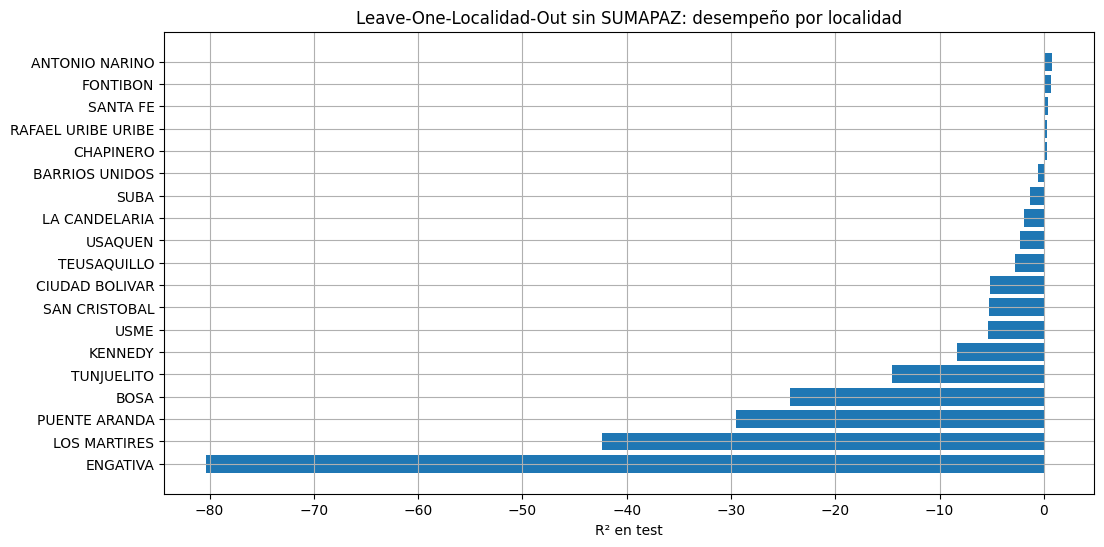


Se guardó el resumen sin SUMAPAZ en: resultados_leave_one_localidad_out_sin_sumapaz.csv


In [6]:
# ============================================================
# VALIDACIÓN ESPACIAL: LEAVE-ONE-LOCALIDAD-OUT EXCLUYENDO SUMAPAZ
# ============================================================
# Este bloque repite la validación espacial excluyendo SUMAPAZ
# del dataset completo para verificar si esa localidad está
# destruyendo la generalización global.
#
# REQUISITOS:
# Deben existir previamente:
#   X
#   y
#
# IMPORTANTE:
# - X debe conservar la columna "localidad"
# - y está en escala original; aquí se transforma con log1p
# ============================================================

# Instalar/importar XGBoost si hace falta
try:
    from xgboost import XGBRegressor
except ImportError:
    !pip install xgboost -q
    from xgboost import XGBRegressor

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ============================================================
# 1. CONSTRUIR X_model Y y_model
# ============================================================

X_model = X.copy()
y_model = y.copy()

# ------------------------------------------------------------
# 1.1 TRANSFORMAR BIMESTRE A REPRESENTACIÓN CÍCLICA
# ------------------------------------------------------------

if "BIMESTRE" in X_model.columns:
    X_model["BIMESTRE"] = pd.to_numeric(X_model["BIMESTRE"], errors="coerce")
    X_model["BIMESTRE_sin"] = np.sin(2 * np.pi * X_model["BIMESTRE"] / 6)
    X_model["BIMESTRE_cos"] = np.cos(2 * np.pi * X_model["BIMESTRE"] / 6)
    X_model = X_model.drop(columns=["BIMESTRE"])
    print("Se transformó 'BIMESTRE' a variables cíclicas: BIMESTRE_sin y BIMESTRE_cos")
else:
    print("La columna 'BIMESTRE' no está presente en X_model")

# ------------------------------------------------------------
# 1.2 CONVERTIR COLUMNAS NUMÉRICAS
# ------------------------------------------------------------

for col in X_model.columns:
    if col != "localidad":
        X_model[col] = pd.to_numeric(X_model[col], errors="coerce")

y_model = pd.to_numeric(y_model, errors="coerce")

# ------------------------------------------------------------
# 1.3 TRANSFORMAR EL TARGET CON log1p
# ------------------------------------------------------------

if (y_model < 0).any():
    raise ValueError("La transformación log1p no puede aplicarse porque existen valores negativos en el target.")

y_model = np.log1p(y_model)

print("Se aplicó transformación log1p al target 'consumo_promedio'.")

# ------------------------------------------------------------
# 1.4 ELIMINAR FILAS CON TARGET NULO
# ------------------------------------------------------------

mask_target_valido = y_model.notna()

X_model = X_model.loc[mask_target_valido].reset_index(drop=True)
y_model = y_model.loc[mask_target_valido].reset_index(drop=True)

print("\nDespués de quitar targets nulos:")
print(f"X_model: {X_model.shape}")
print(f"y_model: {y_model.shape}")

# ============================================================
# 2. VERIFICAR COLUMNA LOCALIDAD
# ============================================================

if "localidad" not in X_model.columns:
    raise ValueError(
        "La columna 'localidad' no está en X. "
        "Debes conservarla en el dataset para la validación espacial."
    )

# ============================================================
# 3. EXCLUIR SUMAPAZ DEL DATASET COMPLETO
# ============================================================

localidad_excluir = "SUMAPAZ"

mask_no_sumapaz = X_model["localidad"] != localidad_excluir

X_model_filtrado = X_model.loc[mask_no_sumapaz].reset_index(drop=True)
y_model_filtrado = y_model.loc[mask_no_sumapaz].reset_index(drop=True)

print(f"\nSe excluyó la localidad: {localidad_excluir}")
print(f"Nuevo tamaño X_model_filtrado: {X_model_filtrado.shape}")
print(f"Nuevo tamaño y_model_filtrado: {y_model_filtrado.shape}")

# ============================================================
# 4. FUNCIÓN AUXILIAR PARA MÉTRICAS
# ============================================================

def calcular_metricas(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    return mae, rmse, r2

# ============================================================
# 5. LISTAR LOCALIDADES DISPONIBLES
# ============================================================

localidades = sorted(X_model_filtrado["localidad"].dropna().unique().tolist())

print("\nLocalidades incluidas en la validación:")
for loc in localidades:
    print(f" - {loc}")

print(f"\nTotal de localidades evaluadas: {len(localidades)}")

# ============================================================
# 6. HIPERPARÁMETROS DEL MEJOR XGBOOST
# ============================================================

xgb_params = {
    "n_estimators": 400,
    "learning_rate": 0.03,
    "max_depth": 3,
    "min_child_weight": 1,
    "subsample": 0.8,
    "colsample_bytree": 1.0,
    "reg_alpha": 0.0,
    "reg_lambda": 1.0,
    "objective": "reg:squarederror",
    "random_state": 42,
    "n_jobs": -1
}

# ============================================================
# 7. LEAVE-ONE-LOCALIDAD-OUT
# ============================================================

resultados_localidad = []
predicciones_por_localidad = {}

for i, loc_test in enumerate(localidades, start=1):
    print("\n" + "=" * 80)
    print(f"Fold {i}/{len(localidades)} - Localidad en TEST: {loc_test}")
    print("=" * 80)

    # --------------------------------------------------------
    # 7.1 Separar TEST
    # --------------------------------------------------------
    mask_test = X_model_filtrado["localidad"] == loc_test

    X_test_loc = X_model_filtrado.loc[mask_test].copy()
    y_test_loc = y_model_filtrado.loc[mask_test].copy()

    X_rest = X_model_filtrado.loc[~mask_test].copy()
    y_rest = y_model_filtrado.loc[~mask_test].copy()

    if len(X_test_loc) < 2 or len(X_rest) < 10:
        print(f"Se omite la localidad {loc_test} por tamaño insuficiente.")
        continue

    # --------------------------------------------------------
    # 7.2 Quitar localidad como predictor
    # --------------------------------------------------------
    X_test_loc_features = X_test_loc.drop(columns=["localidad"])
    X_rest_features = X_rest.drop(columns=["localidad"])

    # --------------------------------------------------------
    # 7.3 Split interno train/validation
    # --------------------------------------------------------
    X_train_loc, X_val_loc, y_train_loc, y_val_loc = train_test_split(
        X_rest_features,
        y_rest,
        test_size=0.20,
        random_state=42
    )

    print(f"Tamaño train: {X_train_loc.shape}")
    print(f"Tamaño val:   {X_val_loc.shape}")
    print(f"Tamaño test:  {X_test_loc_features.shape}")

    # --------------------------------------------------------
    # 7.4 Imputación
    # --------------------------------------------------------
    imputer = SimpleImputer(strategy="median")

    X_train_imp = imputer.fit_transform(X_train_loc)
    X_val_imp   = imputer.transform(X_val_loc)
    X_test_imp  = imputer.transform(X_test_loc_features)

    # --------------------------------------------------------
    # 7.5 Entrenamiento
    # --------------------------------------------------------
    model = XGBRegressor(**xgb_params)

    model.fit(
        X_train_imp,
        y_train_loc.values,
        eval_set=[(X_val_imp, y_val_loc.values)],
        verbose=False
    )

    # --------------------------------------------------------
    # 7.6 Predicción
    # --------------------------------------------------------
    y_train_pred_log = model.predict(X_train_imp)
    y_val_pred_log   = model.predict(X_val_imp)
    y_test_pred_log  = model.predict(X_test_imp)

    # --------------------------------------------------------
    # 7.7 Volver a escala original
    # --------------------------------------------------------
    y_train_real = np.expm1(y_train_loc.values)
    y_val_real   = np.expm1(y_val_loc.values)
    y_test_real  = np.expm1(y_test_loc.values)

    y_train_pred_real = np.expm1(y_train_pred_log)
    y_val_pred_real   = np.expm1(y_val_pred_log)
    y_test_pred_real  = np.expm1(y_test_pred_log)

    # --------------------------------------------------------
    # 7.8 Métricas
    # --------------------------------------------------------
    mae_train, rmse_train, r2_train = calcular_metricas(y_train_real, y_train_pred_real)
    mae_val, rmse_val, r2_val       = calcular_metricas(y_val_real, y_val_pred_real)
    mae_test, rmse_test, r2_test    = calcular_metricas(y_test_real, y_test_pred_real)

    print(f"TRAIN -> MAE: {mae_train:.4f} | RMSE: {rmse_train:.4f} | R²: {r2_train:.4f}")
    print(f"VAL   -> MAE: {mae_val:.4f} | RMSE: {rmse_val:.4f} | R²: {r2_val:.4f}")
    print(f"TEST  -> MAE: {mae_test:.4f} | RMSE: {rmse_test:.4f} | R²: {r2_test:.4f}")

    resultados_localidad.append({
        "localidad_test": loc_test,
        "n_train": len(X_train_loc),
        "n_val": len(X_val_loc),
        "n_test": len(X_test_loc_features),
        "MAE_train": mae_train,
        "RMSE_train": rmse_train,
        "R2_train": r2_train,
        "MAE_val": mae_val,
        "RMSE_val": rmse_val,
        "R2_val": r2_val,
        "MAE_test": mae_test,
        "RMSE_test": rmse_test,
        "R2_test": r2_test
    })

    predicciones_por_localidad[loc_test] = pd.DataFrame({
        "localidad": loc_test,
        "Valor_real": y_test_real,
        "Prediccion": y_test_pred_real,
        "Error_absoluto": np.abs(y_test_real - y_test_pred_real)
    })

# ============================================================
# 8. TABLA FINAL DE RESULTADOS
# ============================================================

df_resultados_spatial_sin_sumapaz = pd.DataFrame(resultados_localidad)

if df_resultados_spatial_sin_sumapaz.empty:
    raise ValueError("No se generaron resultados. Revisa los datos.")

print("\n" + "=" * 80)
print("RESULTADOS POR LOCALIDAD (TEST) - SIN SUMAPAZ")
print("=" * 80)
display(df_resultados_spatial_sin_sumapaz.sort_values(by="R2_test", ascending=False))

# ============================================================
# 9. RESUMEN GLOBAL
# ============================================================

print("\n" + "=" * 80)
print("RESUMEN GLOBAL LEAVE-ONE-LOCALIDAD-OUT - SIN SUMAPAZ")
print("=" * 80)

print(f"Promedio MAE test : {df_resultados_spatial_sin_sumapaz['MAE_test'].mean():.4f}")
print(f"Promedio RMSE test: {df_resultados_spatial_sin_sumapaz['RMSE_test'].mean():.4f}")
print(f"Promedio R² test  : {df_resultados_spatial_sin_sumapaz['R2_test'].mean():.4f}")

print(f"\nMediana MAE test : {df_resultados_spatial_sin_sumapaz['MAE_test'].median():.4f}")
print(f"Mediana RMSE test: {df_resultados_spatial_sin_sumapaz['RMSE_test'].median():.4f}")
print(f"Mediana R² test  : {df_resultados_spatial_sin_sumapaz['R2_test'].median():.4f}")

# ============================================================
# 10. TOP MEJORES Y PEORES
# ============================================================

print("\nTop 5 mejores localidades por R² test (sin SUMAPAZ):")
display(df_resultados_spatial_sin_sumapaz.sort_values(by="R2_test", ascending=False).head(5))

print("\nTop 5 peores localidades por R² test (sin SUMAPAZ):")
display(df_resultados_spatial_sin_sumapaz.sort_values(by="R2_test", ascending=True).head(5))

# ============================================================
# 11. GRÁFICO DE R² POR LOCALIDAD
# ============================================================

df_plot = df_resultados_spatial_sin_sumapaz.sort_values(by="R2_test", ascending=True)

plt.figure(figsize=(12, 6))
plt.barh(df_plot["localidad_test"].astype(str), df_plot["R2_test"])
plt.xlabel("R² en test")
plt.title("Leave-One-Localidad-Out sin SUMAPAZ: desempeño por localidad")
plt.grid(True)
plt.show()

# ============================================================
# 12. GUARDAR RESULTADOS
# ============================================================

ruta_resultados = "resultados_leave_one_localidad_out_sin_sumapaz.csv"
df_resultados_spatial_sin_sumapaz.to_csv(ruta_resultados, index=False)

print(f"\nSe guardó el resumen sin SUMAPAZ en: {ruta_resultados}")

Dataset cargado correctamente.


,año,localidad,BIMESTRE,metros_cubicos,facturas,consumo_promedio,suscriptores_facturados,suscriptores_con_medidor,latitud,longitud,...,WD10M,WD2M,WS10M,WS10M_MAX,WS10M_MIN,WS10M_RANGE,WS2M,WS2M_MAX,WS2M_MIN,WS2M_RANGE
0,2020,USAQUEN,1,4653292,213354,10.905097,212731.0,215097,4.73197,-74.05163,...,89.65,94.8,2.310,6.405,0.140,3.07,1.395,4.175,0.065,2.085
1,2020,CHAPINERO,1,2281601,93362,12.219109,93016.0,93684,4.67040,-74.04338,...,89.65,94.8,2.310,6.405,0.140,3.07,1.395,4.175,0.065,2.085
2,2020,SANTA FE,1,843631,33789,12.483811,33524.0,34703,4.60947,-74.08135,...,78.20,78.8,2.275,6.650,0.205,2.31,1.430,4.735,0.150,1.945
3,2020,SAN CRISTOBAL,1,1771678,80676,10.980205,80311.0,81072,4.58843,-74.07080,...,78.20,78.8,2.275,6.650,0.205,2.31,1.430,4.735,0.150,1.945
4,2020,USME,1,1570282,78240,10.035033,77876.0,79159,4.53286,-74.11451,...,78.20,78.8,2.275,6.650,0.205,2.31,1.430,4.735,0.150,1.945



Dimensiones iniciales del dataset: (596, 49)

Columnas utilizadas en este experimento:
 - latitud
 - longitud
 - consumo_promedio

Dimensiones después de quitar targets nulos: (596, 3)
Se aplicó transformación log1p al target.

División de datos:
Train: (417, 2), (417,)
Val:   (89, 2), (89,)
Test:  (90, 2), (90,)

RESULTADOS EN TRAIN
MAE  : 0.7504
RMSE : 1.7563
R²   : 0.5870

RESULTADOS EN VALIDATION
MAE  : 1.2959
RMSE : 3.5320
R²   : 0.3738

RESULTADOS EN TEST
MAE  : 0.6109
RMSE : 1.0173
R²   : 0.7964

Primeras 10 predicciones en test:


,Valor_real,Prediccion,Error_absoluto
0,11.404461,11.243257,0.161205
1,11.192153,10.644114,0.548039
2,10.600932,10.675889,0.074957
3,15.794589,15.981171,0.186582
4,11.060142,10.651749,0.408393
5,16.104217,15.981171,0.123046
6,10.845302,10.675889,0.169413
7,14.570527,13.815638,0.754889
8,10.067235,9.918685,0.148550
9,12.082005,12.773701,0.691696



20 peores casos en test:


,Valor_real,Prediccion,Error_absoluto
84,21.093750,14.726722,6.367028
56,14.028498,16.548906,2.520409
47,13.672494,15.981171,2.308677
73,14.275903,16.548906,2.273004
44,14.139062,15.981171,1.842109
38,12.483811,10.644114,1.839697
35,14.376812,15.981171,1.604358
69,12.195629,10.644114,1.551515
88,17.271118,15.981171,1.289947
87,9.960999,11.243257,1.282258



Importancia de las variables:


,feature,importance
0,latitud,0.70016
1,longitud,0.29984


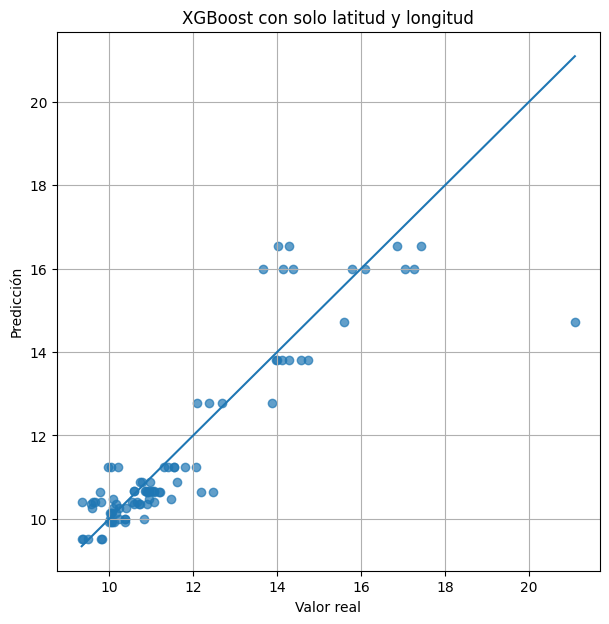


RESUMEN FINAL - SOLO LATITUD Y LONGITUD
Test MAE  : 0.6109
Test RMSE : 1.0173
Test R²   : 0.7964


In [7]:
# ============================================================
# MODELO XGBOOST USANDO SOLO LATITUD Y LONGITUD
# ============================================================
# Este bloque entrena un modelo de regresión usando únicamente:
#   - latitud
#   - longitud
#
# para predecir:
#   - consumo_promedio
#
# Está listo para copiar y pegar en Google Colab.
# ============================================================

# ============================================================
# 1. IMPORTAR LIBRERÍAS
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Instalar/importar XGBoost si hace falta
try:
    from xgboost import XGBRegressor
except ImportError:
    #!pip install xgboost -q
    from xgboost import XGBRegressor

# ============================================================
# 2. CARGAR DATASET
# ============================================================

ruta_archivo = "df_consumo_bime_clima_v3.xlsx"

df = pd.read_excel(ruta_archivo)

print("Dataset cargado correctamente.")
display(df.head())

print(f"\nDimensiones iniciales del dataset: {df.shape}")

# ============================================================
# 3. DEFINIR VARIABLES A USAR
# ============================================================

target = "consumo_promedio"
features = ["latitud", "longitud"]

# Verificar existencia de columnas
columnas_requeridas = features + [target]

for col in columnas_requeridas:
    if col not in df.columns:
        raise ValueError(f"La columna '{col}' no existe en el dataset.")

# ============================================================
# 4. SELECCIONAR SOLO LAS COLUMNAS NECESARIAS
# ============================================================

df_model = df[columnas_requeridas].copy()

print("\nColumnas utilizadas en este experimento:")
for col in df_model.columns:
    print(f" - {col}")

# ============================================================
# 5. CONVERTIR A NUMÉRICO
# ============================================================

for col in features:
    df_model[col] = pd.to_numeric(df_model[col], errors="coerce")

df_model[target] = pd.to_numeric(df_model[target], errors="coerce")

# ============================================================
# 6. ELIMINAR FILAS CON TARGET NULO
# ============================================================

df_model = df_model[df_model[target].notna()].reset_index(drop=True)

print(f"\nDimensiones después de quitar targets nulos: {df_model.shape}")

# ============================================================
# 7. DEFINIR X E y
# ============================================================

X = df_model[features].copy()
y = df_model[target].copy()

# ============================================================
# 8. TRANSFORMAR EL TARGET CON log1p
# ============================================================

if (y < 0).any():
    raise ValueError("La transformación log1p no puede aplicarse porque existen valores negativos en el target.")

y_log = np.log1p(y)

print("Se aplicó transformación log1p al target.")

# ============================================================
# 9. SPLIT TRAIN / VALIDATION / TEST
# ============================================================

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y_log,
    test_size=0.30,
    random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42
)

print("\nDivisión de datos:")
print(f"Train: {X_train.shape}, {y_train.shape}")
print(f"Val:   {X_val.shape}, {y_val.shape}")
print(f"Test:  {X_test.shape}, {y_test.shape}")

# ============================================================
# 10. IMPUTAR VALORES FALTANTES
# ============================================================

imputer = SimpleImputer(strategy="median")

X_train_imp = imputer.fit_transform(X_train)
X_val_imp   = imputer.transform(X_val)
X_test_imp  = imputer.transform(X_test)

# ============================================================
# 11. ENTRENAR XGBOOST
# ============================================================

xgb_model = XGBRegressor(
    n_estimators=400,
    learning_rate=0.03,
    max_depth=3,
    min_child_weight=1,
    subsample=0.8,
    colsample_bytree=1.0,
    reg_alpha=0.0,
    reg_lambda=1.0,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(
    X_train_imp,
    y_train.values,
    eval_set=[(X_train_imp, y_train.values), (X_val_imp, y_val.values)],
    verbose=False
)

# ============================================================
# 12. PREDECIR
# ============================================================

y_train_pred_log = xgb_model.predict(X_train_imp)
y_val_pred_log   = xgb_model.predict(X_val_imp)
y_test_pred_log  = xgb_model.predict(X_test_imp)

# ============================================================
# 13. DEVOLVER A ESCALA ORIGINAL
# ============================================================

y_train_real = np.expm1(y_train.values)
y_val_real   = np.expm1(y_val.values)
y_test_real  = np.expm1(y_test.values)

y_train_pred_real = np.expm1(y_train_pred_log)
y_val_pred_real   = np.expm1(y_val_pred_log)
y_test_pred_real  = np.expm1(y_test_pred_log)

# ============================================================
# 14. FUNCIÓN DE MÉTRICAS
# ============================================================

def calcular_metricas(y_true, y_pred, nombre):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    print("\n==============================")
    print(f"RESULTADOS EN {nombre.upper()}")
    print("==============================")
    print(f"MAE  : {mae:.4f}")
    print(f"RMSE : {rmse:.4f}")
    print(f"R²   : {r2:.4f}")

    return mae, rmse, r2

mae_train, rmse_train, r2_train = calcular_metricas(y_train_real, y_train_pred_real, "train")
mae_val, rmse_val, r2_val       = calcular_metricas(y_val_real, y_val_pred_real, "validation")
mae_test, rmse_test, r2_test    = calcular_metricas(y_test_real, y_test_pred_real, "test")

# ============================================================
# 15. MOSTRAR PREDICCIONES
# ============================================================

resultados_test = pd.DataFrame({
    "Valor_real": y_test_real,
    "Prediccion": y_test_pred_real,
    "Error_absoluto": np.abs(y_test_real - y_test_pred_real)
})

print("\nPrimeras 10 predicciones en test:")
display(resultados_test.head(10))

print("\n20 peores casos en test:")
display(resultados_test.sort_values(by="Error_absoluto", ascending=False).head(20))

# ============================================================
# 16. IMPORTANCIA DE VARIABLES
# ============================================================

importancias = pd.DataFrame({
    "feature": features,
    "importance": xgb_model.feature_importances_
}).sort_values(by="importance", ascending=False)

print("\nImportancia de las variables:")
display(importancias)

# ============================================================
# 17. GRÁFICO REAL VS PREDICHO
# ============================================================

plt.figure(figsize=(7, 7))
plt.scatter(y_test_real, y_test_pred_real, alpha=0.7)

min_val = min(np.min(y_test_real), np.min(y_test_pred_real))
max_val = max(np.max(y_test_real), np.max(y_test_pred_real))
plt.plot([min_val, max_val], [min_val, max_val])

plt.xlabel("Valor real")
plt.ylabel("Predicción")
plt.title("XGBoost con solo latitud y longitud")
plt.grid(True)
plt.show()

# ============================================================
# 18. RESUMEN FINAL
# ============================================================

print("\n==============================")
print("RESUMEN FINAL - SOLO LATITUD Y LONGITUD")
print("==============================")
print(f"Test MAE  : {mae_test:.4f}")
print(f"Test RMSE : {rmse_test:.4f}")
print(f"Test R²   : {r2_test:.4f}")